## Model Comparison, Insights & Critical Reflection

**Load data and best hyperparameters, define the combined train+val set**

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)

features = pd.read_parquet("../outputs/features/daily_consumption_engineered.parquet")

trainval = features.loc["2023-02-01":"2024-08-31"]
test = features.loc["2024-09-01":"2024-10-31"]

y_trainval = trainval["consumption_kwh"]
y_test = test["consumption_kwh"]

print(f"Train+Val: {len(y_trainval)} rows, {y_trainval.index.min()} -> {y_trainval.index.max()}")
print(f"Test: {len(y_test)} rows, {y_test.index.min()} -> {y_test.index.max()}")

with open("../outputs/models/best_hyperparameters.json") as f:
    best_params = json.load(f)
print(best_params)

Train+Val: 578 rows, 2023-02-01 00:00:00 -> 2024-08-31 00:00:00
Test: 61 rows, 2024-09-01 00:00:00 -> 2024-10-31 00:00:00
{'sarima': {'p': 2, 'q': 0, 'P': 1, 'D': 1, 'Q': 1}, 'xgboost': {'n_estimators': 507, 'max_depth': 3, 'learning_rate': 0.1256811598167977, 'subsample': 0.7553471381943498, 'colsample_bytree': 0.8847936528260443, 'reg_alpha': 0.6523685294345549, 'reg_lambda': 0.7763628833688613}, 'lstm': {'units': 112, 'dropout': 0.22754770895097912, 'learning_rate': 0.0013495870937462009, 'batch_size': 8}}


**Retrain SARIMA on train+val, forecast test**

In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sp = best_params["sarima"]
final_sarima_full = SARIMAX(y_trainval, order=(sp["p"], 1, sp["q"]),
                             seasonal_order=(sp["P"], sp["D"], sp["Q"], 7),
                             enforce_stationarity=False, enforce_invertibility=False)
final_sarima_full_fit = final_sarima_full.fit(disp=False)

sarima_test_forecast = final_sarima_full_fit.forecast(steps=len(y_test))

sarima_mae = mean_absolute_error(y_test, sarima_test_forecast)
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_test_forecast))
sarima_mape = np.mean(np.abs((y_test - sarima_test_forecast) / y_test)) * 100
print(f"SARIMA TEST — MAE: {sarima_mae:.1f}, RMSE: {sarima_rmse:.1f}, MAPE: {sarima_mape:.2f}%")

d:\MSc\Projects\module_04_machine_learning\cw\ml_recon_sl\ml-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\MSc\Projects\module_04_machine_learning\cw\ml_recon_sl\ml-venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMA TEST — MAE: 1426.3, RMSE: 1793.0, MAPE: 9.34%


**Retrain XGBoost on train+val, forecast test**

In [3]:
import xgboost as xgb

LAG_ROLLING_COLS = ["lag_1", "lag_7", "lag_14", "lag_30", "rolling_mean_7", "rolling_std_7", "rolling_mean_30"]
TARGET_CALENDAR_COLS = ["day_of_week", "is_weekend", "month", "is_sl_public_holiday", "is_tariff_revision_day", "days_since_tariff_revision"]
HORIZON = 30

def build_long_format(feat_df, horizon, target_start, target_end):
    rows = []
    valid_origins = feat_df.dropna(subset=LAG_ROLLING_COLS).index
    for origin in valid_origins:
        for h in range(1, horizon + 1):
            target_date = origin + pd.Timedelta(days=h)
            if target_date not in feat_df.index:
                continue
            if not (pd.Timestamp(target_start) <= target_date <= pd.Timestamp(target_end)):
                continue
            row = {col: feat_df.loc[origin, col] for col in LAG_ROLLING_COLS}
            row["horizon_step"] = h
            for col in TARGET_CALENDAR_COLS:
                row[f"target_{col}"] = feat_df.loc[target_date, col]
            row["target"] = feat_df.loc[target_date, "consumption_kwh"]
            row["origin_date"] = origin
            row["target_date"] = target_date
            rows.append(row)
    return pd.DataFrame(rows)

FEATURE_COLS = LAG_ROLLING_COLS + ["horizon_step"] + [f"target_{c}" for c in TARGET_CALENDAR_COLS]

xgb_trainval_long = build_long_format(features, HORIZON, "2023-02-01", "2024-08-31")
xgb_test_long = build_long_format(features, HORIZON, "2024-09-01", "2024-10-31")

xp = best_params["xgboost"]
final_xgb_full = xgb.XGBRegressor(**xp, random_state=SEED)
final_xgb_full.fit(xgb_trainval_long[FEATURE_COLS], xgb_trainval_long["target"])

pred_test_xgb = final_xgb_full.predict(xgb_test_long[FEATURE_COLS])
xgb_mae = mean_absolute_error(xgb_test_long["target"], pred_test_xgb)
xgb_rmse = np.sqrt(mean_squared_error(xgb_test_long["target"], pred_test_xgb))
xgb_mape = np.mean(np.abs((xgb_test_long["target"] - pred_test_xgb) / xgb_test_long["target"])) * 100
print(f"XGBoost TEST — MAE: {xgb_mae:.1f}, RMSE: {xgb_rmse:.1f}, MAPE: {xgb_mape:.2f}%")


XGBoost TEST — MAE: 2022.1, RMSE: 2539.7, MAPE: 12.08%


**Check whether test-period consumption represents a level/trend shift**

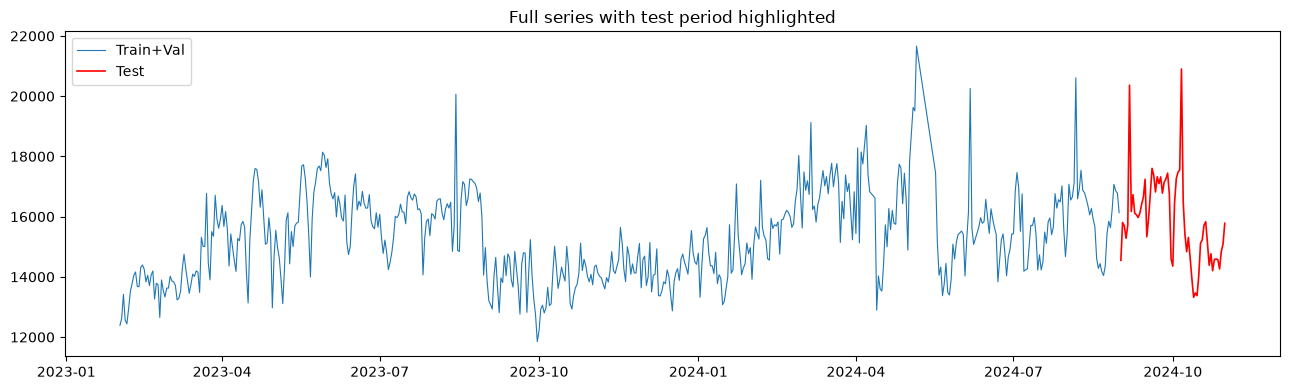

Sept-Oct 2023 mean: 13816.1
Sept-Oct 2024 mean: 15889.2
Overall train+val mean: 15371.6


In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_trainval.index, y_trainval.values, label="Train+Val", linewidth=0.8)
ax.plot(y_test.index, y_test.values, label="Test", linewidth=1.2, color="red")
ax.legend()
ax.set_title("Full series with test period highlighted")
plt.tight_layout()
plt.show()

sept_oct_2023 = features.loc["2023-09-01":"2023-10-31", "consumption_kwh"]
sept_oct_2024 = features.loc["2024-09-01":"2024-10-31", "consumption_kwh"]
print(f"Sept-Oct 2023 mean: {sept_oct_2023.mean():.1f}")
print(f"Sept-Oct 2024 mean: {sept_oct_2024.mean():.1f}")
print(f"Overall train+val mean: {y_trainval.mean():.1f}")


**Retrain LSTM on train+val, forecast test**

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(SEED)
LOOKBACK = 30

scaler_full = MinMaxScaler()
scaler_full.fit(y_trainval.values.reshape(-1, 1))
scaled_full_series = pd.Series(scaler_full.transform(features["consumption_kwh"].values.reshape(-1, 1)).flatten(), index=features.index)

dow_sin = np.sin(2 * np.pi * features["day_of_week"] / 7)
dow_cos = np.cos(2 * np.pi * features["day_of_week"] / 7)
calendar = pd.DataFrame({"dow_sin": dow_sin, "dow_cos": dow_cos, "is_weekend": features["is_weekend"]}, index=features.index)

def build_windows_v2(series, calendar_df, lookback, horizon, target_start, target_end):
    X_cons, X_cal_past, X_cal_future, y, origins = [], [], [], [], []
    values, cal_values, dates = series.values, calendar_df.values, series.index
    for i in range(lookback, len(series) - horizon + 1):
        target_dates = dates[i:i + horizon]
        if target_dates[0] >= pd.Timestamp(target_start) and target_dates[-1] <= pd.Timestamp(target_end):
            X_cons.append(values[i - lookback:i])
            X_cal_past.append(cal_values[i - lookback:i])
            X_cal_future.append(cal_values[i:i + horizon])
            y.append(values[i:i + horizon])
            origins.append(dates[i])
    return np.array(X_cons), np.array(X_cal_past), np.array(X_cal_future), np.array(y), origins

Xc_tv, Xcalp_tv, Xcalf_tv, y_tv, _ = build_windows_v2(scaled_full_series, calendar, LOOKBACK, HORIZON, "2023-02-01", "2024-08-31")
Xc_te, Xcalp_te, Xcalf_te, y_te, test_origins = build_windows_v2(scaled_full_series, calendar, LOOKBACK, HORIZON, "2024-09-01", "2024-10-31")

lp = best_params["lstm"]
past_cons_in = layers.Input(shape=(LOOKBACK, 1))
past_cal_in = layers.Input(shape=(LOOKBACK, 3))
future_cal_in = layers.Input(shape=(HORIZON, 3))
enc_in = layers.Concatenate(axis=-1)([past_cons_in, past_cal_in])
enc_out = layers.LSTM(lp["units"])(enc_in)
fut_dense = layers.Dense(32, activation="relu")(layers.Flatten()(future_cal_in))
merged = layers.Dense(64, activation="relu")(layers.Concatenate()([enc_out, fut_dense]))
merged = layers.Dropout(lp["dropout"])(merged)
out = layers.Dense(HORIZON)(merged)

final_lstm_full = keras.Model([past_cons_in, past_cal_in, future_cal_in], out)
final_lstm_full.compile(optimizer=keras.optimizers.Adam(learning_rate=lp["learning_rate"]), loss="mse")
final_lstm_full.fit(
    [Xc_tv.reshape(-1, LOOKBACK, 1), Xcalp_tv, Xcalf_tv], y_tv,
    epochs=50, batch_size=lp["batch_size"], verbose=0,
)

pred_test_lstm_scaled = final_lstm_full.predict([Xc_te.reshape(-1, LOOKBACK, 1), Xcalp_te, Xcalf_te])
pred_test_lstm = scaler_full.inverse_transform(pred_test_lstm_scaled)
actual_test_lstm = scaler_full.inverse_transform(y_te)

lstm_mae = mean_absolute_error(actual_test_lstm.flatten(), pred_test_lstm.flatten())
lstm_rmse = np.sqrt(mean_squared_error(actual_test_lstm.flatten(), pred_test_lstm.flatten()))
lstm_mape = np.mean(np.abs((actual_test_lstm - pred_test_lstm) / actual_test_lstm)) * 100
print(f"LSTM TEST — MAE: {lstm_mae:.1f}, RMSE: {lstm_rmse:.1f}, MAPE: {lstm_mape:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
LSTM TEST — MAE: 1286.7, RMSE: 1617.4, MAPE: 7.94%


**Build the full comparison table and overlay all three test forecasts**

                    Model  Val MAE  Val RMSE  Val MAPE  Test MAE  Test RMSE  \
0  SARIMA(2,1,0)(1,1,1,7)    871.8    1150.5      5.47   1426.29    1793.00   
1           LSTM+calendar    886.8    1195.2      5.54   1286.72    1617.40   
2                 XGBoost    839.3    1107.4      5.31   2022.06    2539.68   

   Test MAPE  
0       9.34  
1       7.94  
2      12.08  


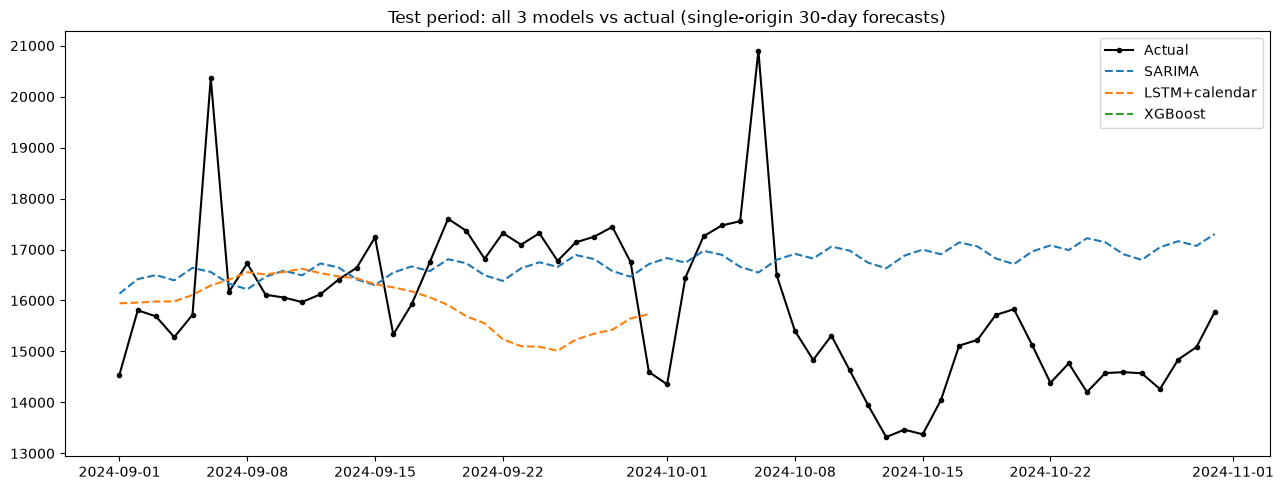

In [6]:
comparison_table = pd.DataFrame({
    "Model": ["SARIMA(2,1,0)(1,1,1,7)", "LSTM+calendar", "XGBoost"],
    "Val MAE": [871.8, 886.8, 839.3],
    "Val RMSE": [1150.5, 1195.2, 1107.4],
    "Val MAPE": [5.47, 5.54, 5.31],
    "Test MAE": [sarima_mae, lstm_mae, xgb_mae],
    "Test RMSE": [sarima_rmse, lstm_rmse, xgb_rmse],
    "Test MAPE": [sarima_mape, lstm_mape, xgb_mape],
})
print(comparison_table.round(2))
comparison_table.to_csv("../outputs/reports/model_comparison.csv", index=False)

# Overlay all three forecasts against actual for the test period
lstm_test_by_date = pd.Series(pred_test_lstm[0], index=pd.date_range(test_origins[0], periods=HORIZON, freq="D"))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index, y_test.values, label="Actual", color="black", linewidth=1.5, marker="o", markersize=3)
ax.plot(y_test.index, sarima_test_forecast.values, label="SARIMA", linestyle="--")
ax.plot(lstm_test_by_date.index, lstm_test_by_date.values, label="LSTM+calendar", linestyle="--")
xgb_test_first_origin = xgb_test_long[xgb_test_long["origin_date"] == xgb_test_long["origin_date"].min()].sort_values("horizon_step")
ax.plot(xgb_test_first_origin["target_date"], final_xgb_full.predict(xgb_test_first_origin[FEATURE_COLS]), label="XGBoost", linestyle="--")
ax.legend()
ax.set_title("Test period: all 3 models vs actual (single-origin 30-day forecasts)")
plt.tight_layout()
plt.show()

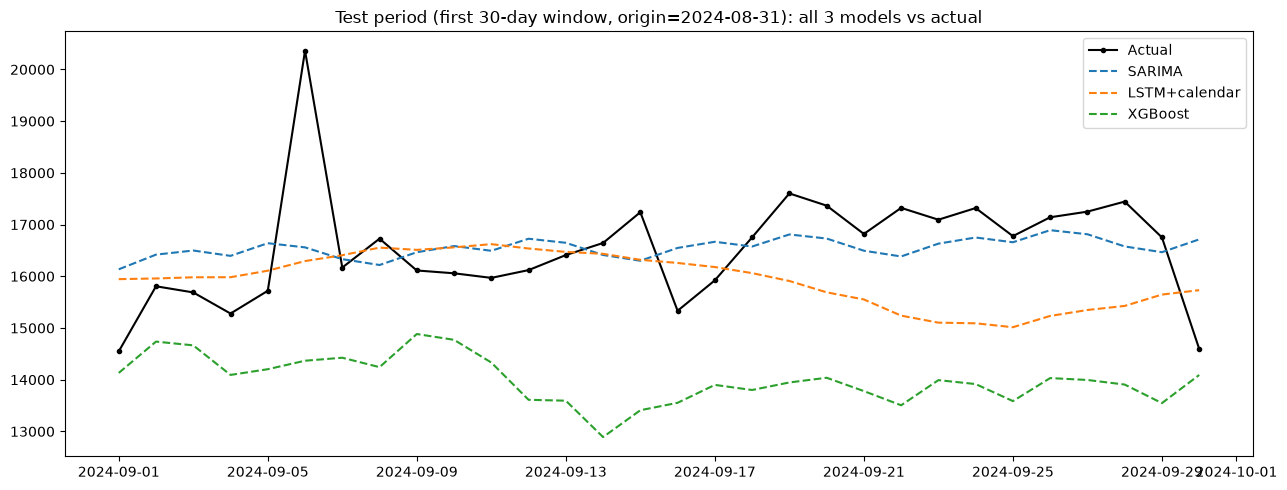

In [26]:
sarima_first30 = sarima_test_forecast.iloc[:30]

xgb_origin_aug31 = xgb_test_long[xgb_test_long["origin_date"] == pd.Timestamp("2024-08-31")].sort_values("horizon_step")
xgb_first30_pred = final_xgb_full.predict(xgb_origin_aug31[FEATURE_COLS])
xgb_first30_dates = xgb_origin_aug31["target_date"]

actual_first30 = y_test.iloc[:30]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(actual_first30.index, actual_first30.values, label="Actual", color="black", linewidth=1.5, marker="o", markersize=3)
ax.plot(sarima_first30.index, sarima_first30.values, label="SARIMA", linestyle="--")
ax.plot(lstm_test_by_date.index, lstm_test_by_date.values, label="LSTM+calendar", linestyle="--")
ax.plot(xgb_first30_dates, xgb_first30_pred, label="XGBoost", linestyle="--")
ax.legend()
ax.set_title("Test period (first 30-day window, origin=2024-08-31): all 3 models vs actual")
plt.tight_layout()
plt.show()


**Residual analysis over the full test period**

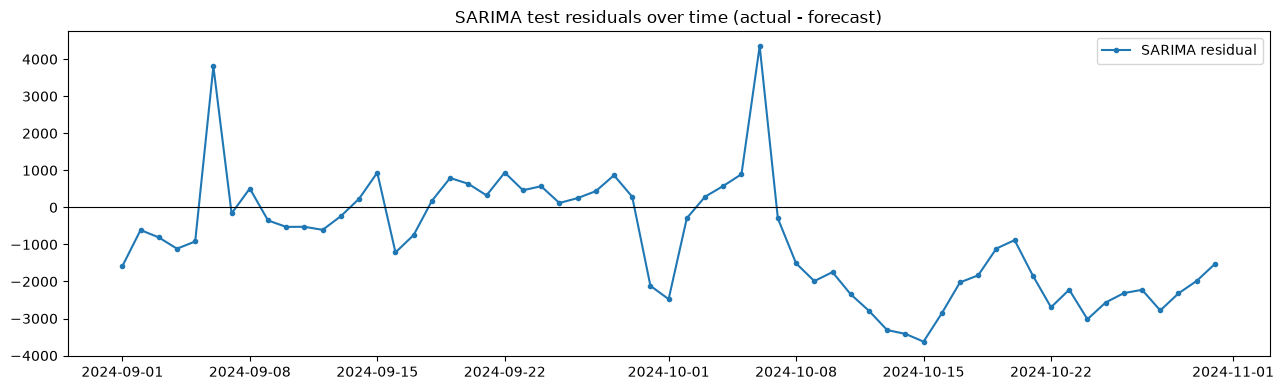

SARIMA residual mean (bias): -853.9143799778434
XGBoost residual mean (bias): 2001.697374172581


In [27]:
sarima_resid = y_test.values - sarima_test_forecast.values
xgb_resid = xgb_test_long["target"].values - final_xgb_full.predict(xgb_test_long[FEATURE_COLS])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_test.index, sarima_resid, label="SARIMA residual", marker="o", markersize=3)
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
ax.set_title("SARIMA test residuals over time (actual - forecast)")
plt.tight_layout()
plt.show()

print("SARIMA residual mean (bias):", sarima_resid.mean())
print("XGBoost residual mean (bias):", xgb_resid.mean())